In [2]:
#importing libraries
from sklearn.utils import resample
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split



In [3]:
#Reading csv into dataframe
df=pd.read_csv(r"C:\Users\ddnri\OneDrive\creditcard.csv")
#Printing data frame
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
#shows class imbalance
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
#Handling imbalanced data, Making dataset balanced
x=df.drop('Class',axis=1)
y=df['Class']
sm=SMOTE()
x_res,y_res=sm.fit_resample(x,y)
df1=pd.DataFrame(x_res,columns=x.columns)
df1['Class']=y_res
print(pd.Series(df1['Class']).value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [6]:
#checking null values in each column
df1.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
#Removing Duplicate rows
df1.drop_duplicates(inplace=True)
#Printing column names
df1.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [8]:
#Performing Standardisation 
ss=StandardScaler()
df1['Time']=ss.fit_transform(df1[['Time']])
df1['Amount']=ss.fit_transform(df1[['Amount']])
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.814225,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.240833,0
1,-1.814225,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.422736,0
2,-1.814204,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.275230,0
3,-1.814204,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.122869,0
4,-1.814183,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.118794,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,-1.551262,-3.523538,4.070751,-5.696258,4.828255,-3.663952,-0.850263,-5.631694,0.051306,-0.032293,...,1.832102,0.117422,0.468321,-0.094711,-1.027098,-0.000208,-0.998508,-0.076528,0.008173,1
568626,-1.222020,-28.627364,15.919440,-29.551841,6.452034,-20.853073,-4.871313,-19.545332,18.812838,-3.639063,...,1.806318,-2.127983,-1.324720,0.170523,2.059644,-0.210417,1.298220,0.379048,0.016693,1
568627,-0.034463,-1.120174,1.622388,-1.159504,2.945801,-2.812731,1.184686,-2.230878,-3.166004,-0.743833,...,-1.501982,1.027098,0.256489,0.227047,0.461684,0.013679,0.563541,0.309024,0.917631,1
568628,-0.526355,-1.138169,1.678432,-2.817813,3.069910,-0.638125,-1.023493,-1.856448,0.589615,-0.193501,...,0.028472,-0.342988,0.109778,-0.269447,0.175878,-0.329622,-0.464323,0.320242,-0.430208,1


In [9]:
#Handling Outliers using z-score method
for col in df.columns:
    mu=df[col].mean()
    sig=df[col].std()
    df1['z-score']=(df1[col]-mu)/sig
    df1[(df1['z-score']>-3)&(df1['z-score']<3)]
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,z-score
0,-1.814225,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.240833,0,-0.041599
1,-1.814225,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.422736,0,-0.041599
2,-1.814204,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.275230,0,-0.041599
3,-1.814204,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.122869,0,-0.041599
4,-1.814183,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.118794,0,-0.041599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,-1.551262,-3.523538,4.070751,-5.696258,4.828255,-3.663952,-0.850263,-5.631694,0.051306,-0.032293,...,0.117422,0.468321,-0.094711,-1.027098,-0.000208,-0.998508,-0.076528,0.008173,1,24.039010
568626,-1.222020,-28.627364,15.919440,-29.551841,6.452034,-20.853073,-4.871313,-19.545332,18.812838,-3.639063,...,-2.127983,-1.324720,0.170523,2.059644,-0.210417,1.298220,0.379048,0.016693,1,24.039010
568627,-0.034463,-1.120174,1.622388,-1.159504,2.945801,-2.812731,1.184686,-2.230878,-3.166004,-0.743833,...,1.027098,0.256489,0.227047,0.461684,0.013679,0.563541,0.309024,0.917631,1,24.039010
568628,-0.526355,-1.138169,1.678432,-2.817813,3.069910,-0.638125,-1.023493,-1.856448,0.589615,-0.193501,...,-0.342988,0.109778,-0.269447,0.175878,-0.329622,-0.464323,0.320242,-0.430208,1,24.039010


In [10]:
#Handling Outliers using iqr method
for col1 in df.columns:
    q1=df[col1].quantile(0.25)
    q3=df[col1].quantile(0.75)
    iqr=q3-q1
    upp=q3+1.5*iqr
    low=q1-1.5*iqr
    df[(df[col1]>=low)&(df[col1]<=upp)]
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


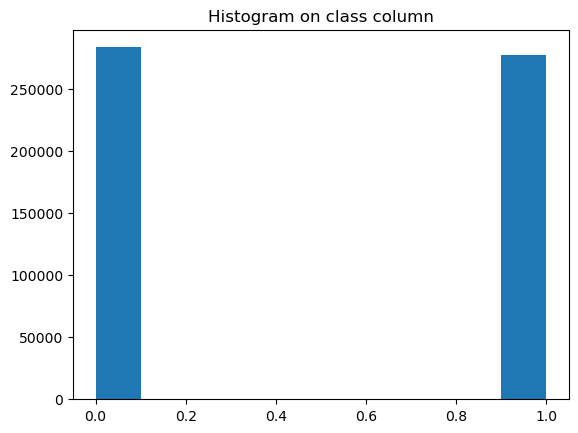

In [11]:
#Ploting a histogram on class column
plt.hist(df1['Class'])
plt.title("Histogram on class column")
plt.show()

In [12]:
x = df1.drop(columns=['Class','z-score'])
y = df1['Class']

In [13]:
y

0         0
1         0
2         0
3         0
4         0
         ..
568625    1
568626    1
568627    1
568628    1
568629    1
Name: Class, Length: 560156, dtype: int64

In [22]:
x_sample, _, y_sample, _ = train_test_split(
    x, y,
    train_size=10000,
    random_state=42,
    stratify=y          # <-- this makes it stratified
)
y_sample=y_sample.astype(int)

# Verify class balance is preserved
print(y_sample.value_counts())

Class
0    5057
1    4943
Name: count, dtype: int64


In [23]:
model = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42)


In [24]:
fs_seq = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=15,
    direction='forward',
    scoring='roc_auc',
    cv=2,
    n_jobs=-1
)

In [25]:
fs_seq.fit(x_sample, y_sample)

,estimator,LogisticRegre...solver='saga')
,n_features_to_select,15
,tol,None
,direction,'forward'
,scoring,'roc_auc'
,cv,2
,n_jobs,-1
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [26]:
sfs_features = x.columns[fs_seq.get_support()].tolist()


In [27]:
print(sfs_features)

['V4', 'V6', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V16', 'V17', 'V18', 'V19', 'V22', 'V23']
